# 🔦 Interactive Simulator: The Magic of Light Rays

### Welcome, Explorers!
Today we are going to learn how light moves. In the real world, light moves so fast we can't see the individual "rays" traveling through the air. 

But with code, we can slow time down and draw exactly how light travels from a tree, through a tiny hole, and onto our bedroom wall!

**Teacher Instructions:** Run the code blocks below to show the class how the Camera Obscura works.

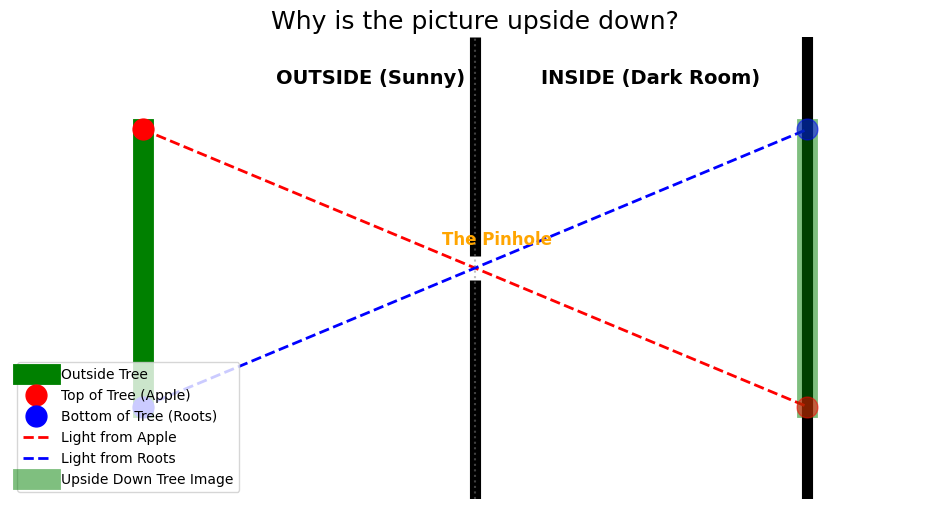

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def draw_camera_obscura():
    """Simulates light rays traveling from an object through a pinhole."""
    plt.figure(figsize=(12, 6))
    
    # 1. Draw the Camera/Room walls
    plt.plot([0, 0], [10, 0.5], 'k-', lw=8, solid_capstyle='butt')  # Top Wall
    plt.plot([0, 0], [-10, -0.5], 'k-', lw=8, solid_capstyle='butt') # Bottom Wall
    plt.plot([5, 5], [10, -10], 'k-', lw=8) # Back Wall (Screen)
    
    # 2. Draw the "Tree" outside (Left side)
    tree_x = -5
    tree_top = 6
    tree_bottom = -6
    plt.plot([tree_x, tree_x], [tree_bottom, tree_top], 'g-', lw=15, label="Outside Tree")
    plt.plot(tree_x, tree_top, 'ro', markersize=15, label="Top of Tree (Apple)")
    plt.plot(tree_x, tree_bottom, 'bo', markersize=15, label="Bottom of Tree (Roots)")
    
    # 3. Draw the Light Rays (Traveling in straight lines!)
    # Ray from the Top (Red Apple) goes through the hole (0,0) and hits the bottom
    plt.plot([tree_x, 5], [tree_top, -tree_top], 'r--', lw=2, label="Light from Apple")
    
    # Ray from the Bottom (Blue Roots) goes through the hole (0,0) and hits the top
    plt.plot([tree_x, 5], [tree_bottom, -tree_bottom], 'b--', lw=2, label="Light from Roots")
    
    # 4. Draw the projected image on the back wall
    plt.plot([5, 5], [-tree_top, -tree_bottom], 'g-', lw=15, alpha=0.5, label="Upside Down Tree Image")
    plt.plot(5, -tree_top, 'ro', markersize=15, alpha=0.5)
    plt.plot(5, -tree_bottom, 'bo', markersize=15, alpha=0.5)

    # Formatting the classroom diagram
    plt.axvline(0, color='gray', linestyle=':', alpha=0.5)
    plt.text(-3, 8, "OUTSIDE (Sunny)", fontsize=14, fontweight='bold')
    plt.text(1, 8, "INSIDE (Dark Room)", fontsize=14, fontweight='bold')
    plt.text(-0.5, 1, "The Pinhole", fontsize=12, fontweight='bold', color='orange')
    
    plt.title("Why is the picture upside down?", fontsize=18)
    plt.xlim(-7, 7)
    plt.ylim(-10, 10)
    plt.axis('off')
    plt.legend(loc='lower left')
    plt.show()

# Run the simulation!
draw_camera_obscura()

### 🔍 What did we just learn?
Look at the red dotted line. The light from the apple on the top of the tree travels in a straight line. It goes right through the pinhole, and because it cannot bend, it ends up at the **bottom** of the back wall. 

Light travels in straight lines!

---

### The Big Trade-Off: Brightness vs. Sharpness
What happens if we make the hole bigger? Will the picture look better?
Let's use code to simulate what the picture on the wall looks like with three different hole sizes.

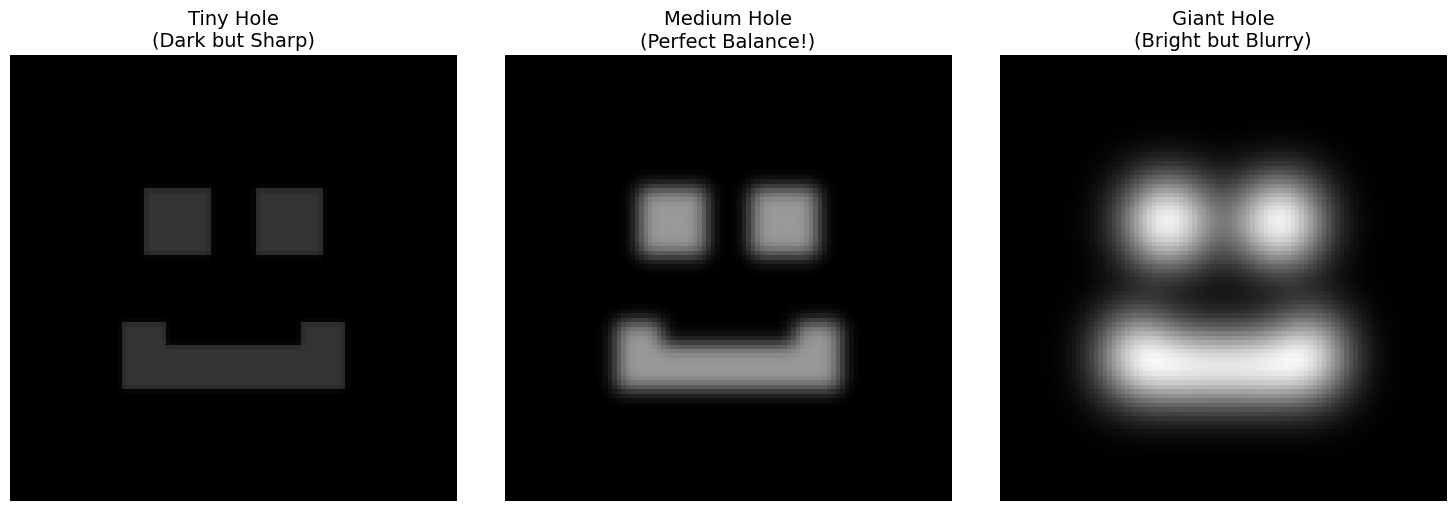

In [2]:
from scipy.ndimage import gaussian_filter

def simulate_pinhole_sizes():
    """Simulates how hole size affects image blur and brightness."""
    # Create a simple "digital picture" of a smiley face
    grid = np.zeros((100, 100))
    
    # Draw Eyes
    grid[30:45, 30:45] = 1.0
    grid[30:45, 55:70] = 1.0
    
    # Draw Mouth
    grid[65:75, 25:75] = 1.0
    grid[60:75, 25:35] = 1.0
    grid[60:75, 65:75] = 1.0
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Tiny Pinhole (Very Sharp, Very Dark)
    # Math note: Gaussian filter simulates the Circle of Confusion overlapping
    tiny_hole = gaussian_filter(grid, sigma=0.5) * 0.2  # Dark (0.2x brightness)
    axes[0].imshow(tiny_hole, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title("Tiny Hole\n(Dark but Sharp)", fontsize=14)
    axes[0].axis('off')
    
    # 2. Medium Pinhole (Goldilocks Zone)
    medium_hole = gaussian_filter(grid, sigma=2.0) * 0.6 # Medium brightness
    axes[1].imshow(medium_hole, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title("Medium Hole\n(Perfect Balance!)", fontsize=14)
    axes[1].axis('off')
    
    # 3. Giant Pinhole (Very Bright, Very Blurry)
    giant_hole = gaussian_filter(grid, sigma=6.0) * 1.5 # Bright (1.5x brightness)
    axes[2].imshow(giant_hole, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title("Giant Hole\n(Bright but Blurry)", fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the simulation!
simulate_pinhole_sizes()

### 📝 The Rules of the Pinhole
1. **Big Holes:** Let in lots of light (very bright), but the light rays get all mixed up (very blurry).
2. **Tiny Holes:** Keep the light rays perfectly organized (very sharp), but don't let enough light in (very dark).

When you build your Camera Obscura, try to find the perfect medium-sized hole!